# QMC on Manifolds

## Setup

In [1]:
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import scipy.stats
import qmcpy as qp
import time
import os
# import qmcpy as qp
import matplotlib
from matplotlib import pyplot
pyplot.style.use("seaborn-v0_8-whitegrid")
# import pandas as pd
# COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv("../../../xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
# pyplot.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=COLORS)
COLORS = ["xkcd:purple","xkcd:blue","xkcd:green","xkcd:red","xkcd:orange","xkcd:cyan","xkcd:brown","xkcd:yellow"]
LINESTYLES = ['solid','dotted','dashed','dashdot',(0, (1, 1))]
DEFAULTFONTSIZE = 30
pyplot.rcParams['xtick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['ytick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['ytick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['axes.titlesize'] = DEFAULTFONTSIZE
pyplot.rcParams['figure.titlesize'] = DEFAULTFONTSIZE
pyplot.rcParams["axes.labelsize"] = DEFAULTFONTSIZE
pyplot.rcParams['legend.fontsize'] = DEFAULTFONTSIZE
pyplot.rcParams['font.size'] = DEFAULTFONTSIZE
pyplot.rcParams['lines.linewidth'] = 5
pyplot.rcParams['lines.markersize'] = 15
PW = 30 # inches

## Sphere

In [60]:
def kernel_sphere_a(x, y):
    assert x.size(-1)==3
    assert y.size(-1)==3
    y = 2-torch.linalg.norm(x-y,dim=-1)
    return y/(2/3)
def kernel_sphere_b(x, y):
    assert x.size(-1)==3 
    assert y.size(-1)==3
    y = 48*torch.exp(-12*torch.linalg.norm(x-y,dim=-1)**2)
    return y/(1-np.exp(-48))
def unif_to_sphere(u):
    assert u.size(-1)==2
    t = torch.sqrt(u[...,1]-u[...,1]**2)
    x = torch.stack([
        2*torch.cos(2*np.pi*u[...,0])*t,
        2*torch.sin(2*np.pi*u[...,0])*t,
        1-2*u[...,1],
        ],dim=-1)
    return x
def sphere_to_unif(x):
    u1 = (1-x[...,2])/2
    t = torch.sqrt(u1-u1**2)
    u0 = (torch.atan2(x[...,1]/(2*t),x[...,0]/(2*t))%(2*np.pi))/(2*np.pi)
    u = torch.stack([
        u0,
        u1,
        ],dim=-1)
    return u
def discrepancy(kernel, x, w, return_kmat=False):
    assert x.ndim>=2
    assert x.size(-2)==w.size(-1)
    kmat = kernel(x[...,:,None,:],x[...,None,:,:]) # (...,n,n)
    discrep = torch.einsum("...i,...ij,...j->...",w,kmat,w)-1 # (...,)
    if return_kmat:
        return discrep,kmat 
    else:
        return discrep

In [120]:
def opt_weights(x, kernel):
    kmat = kernel(x[...,:,None,:],x[...,None,:,:]) # (...,n,n)
    b = torch.ones(kmat.size(-1)) # (...,n,)
    L = torch.linalg.cholesky(kmat,upper=False) # (...,n,n)
    w = torch.cholesky_solve(b[...,None],L,upper=False)[...,0] # (...,n)
    return w
def opt_points_weights(
        n,
        kernel,
        opt_iters = 100,
        eps_kmat = 0,
        lm_relaxation = 1e-1,
        lm_relaxation_threshold = 1,
        lm_lr = 1,
        rng = None,
        verbose = None, 
        verbose_indent = 4,
        ):
    if rng is None: rng = torch.Generator()
    u = np.sqrt(2)*torch.erfinv(2*torch.rand((n-1)*2,generator=rng)-1) # ((n-1)*2,)
    eyen = torch.eye(n)
    eyeQ = torch.eye((n-1)*2)
    onesn = torch.ones(n)
    if verbose is None: verbose = int(np.ceil(opt_iters/20))
    if verbose:
        _s = "%-15s | %-15s | %-15s | %-15s "%("iter of %d"%opt_iters,"discrep","eps_kmat","lm_relaxation")
        print(" "*verbose_indent+_s)
        print(" "*verbose_indent+"~"*len(_s))
    for i in range(opt_iters+1):
        notes = ""
        def discrepancy_loss(u, eps_kmat):
            u = u.reshape((n-1,2))
            u = torch.cat([torch.zeros((1,2)),u],dim=0)
            x = unif_to_sphere(1/2*(1+torch.erf(u/np.sqrt(2))))
            kmat = kernel(x[:,None,:],x[None,:,:]) # (n,n)
            try:
                L = torch.linalg.cholesky(kmat+eps_kmat/2*eyen,upper=False) # (n,n)
                eps_kmat_new = eps_kmat/2
            except:
                L = torch.linalg.cholesky(kmat+eps_kmat*eyen,upper=False) # (n,n)
                eps_kmat_new = eps_kmat
            v = torch.linalg.solve_triangular(L,onesn[...,None],upper=False)[...,0]
            discrep = 1-(v**2).sum()
            return v,(v,x,L,discrep,eps_kmat_new*torch.ones(1))
        (J,),(resid,x,L,discrep,eps_kmat_new) = torch.func.jacrev(discrepancy_loss,argnums=(0,),has_aux=True)(u,eps_kmat)
        eps_kmat = eps_kmat_new
        if verbose and (i%verbose==0 or i==opt_iters):
            _s = "%-15d | %-15.1e | %-15.1e | %-15.1e"%(i,discrep,eps_kmat,lm_relaxation)
            print(" "*verbose_indent+_s)
        if i==opt_iters:
            w = torch.cholesky_solve(onesn[...,None],L,upper=False)[...,0]
            break
        H = torch.einsum("ij,ik->jk",J,J) # (Q,Q)
        fails = True # flags for Cholesky factorization failure
        while True: # continue to double lm_relaxation until the Cholesky factorization doesn't fail
            L,fails = torch.linalg.cholesky_ex(H+lm_relaxation*eyeQ,upper=False)
            fails = fails.to(bool)
            if ~fails: break
            if lm_relaxation>=lm_relaxation_threshold:
                if "LM relax fail, " not in notes:
                    notes += "LM relax fail, "
                break
            lm_relaxation *= 2
        rhs = torch.einsum("ij,i->j",J,resid) # (Q,),  vectorized J^* resid
        delta = torch.cholesky_solve(rhs[:,None],L,upper=False)[:,0] # (R,Q), (J^* J + lm_relaxation I)^{-1} J^* resid
        u += lm_lr*delta # update theta
    print()
    return x,w
opt_points_weights(
    n = 2**7, 
    kernel = kernel_sphere_b,
    rng=torch.Generator().manual_seed(17));

    iter of 100     | discrep         | eps_kmat        | lm_relaxation   
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0               | 1.1e-01         | 0.0e+00         | 1.0e-01        
    5               | 3.1e-02         | 0.0e+00         | 1.0e-01        
    10              | 2.3e-02         | 0.0e+00         | 1.0e-01        
    15              | 1.4e-02         | 0.0e+00         | 1.0e-01        
    20              | 1.3e-02         | 0.0e+00         | 1.0e-01        
    25              | 1.0e-02         | 0.0e+00         | 1.0e-01        
    30              | 9.6e-03         | 0.0e+00         | 1.0e-01        
    35              | 8.5e-03         | 0.0e+00         | 1.0e-01        
    40              | 8.4e-03         | 0.0e+00         | 1.0e-01        
    45              | 7.0e-03         | 0.0e+00         | 1.0e-01        
    50              | 7.2e-03         | 0.0e+00         | 1.0e-01        
    55              | 6.4e-03       

In [121]:
def get_sphere_iid_x_equal_w(n, rng=None):
    if rng is None: rng = torch.Generator()
    x = unif_to_sphere(torch.rand(n,2,generator=rng)) # (n,3)
    w = torch.ones(n)/n
    return x,w
def get_sphere_ldtf_x_equal_w(n, rng=None):
    if rng is None: rng = torch.Generator()
    x = unif_to_sphere(torch.from_numpy(qp.Faure(2,seed=17,randomize="NUS")(n)))  # (n,3)
    w = torch.ones(n)/n
    return x,w
def get_sphere_iid_x_opt_w_A(n, rng=None):
    if rng is None: rng = torch.Generator()
    x = unif_to_sphere(torch.rand(n,2,generator=rng)) # (n,3)
    w = opt_weights(x,kernel_sphere_a)
    return x,w
def get_sphere_iid_x_opt_w_B(n, rng=None):
    if rng is None: rng = torch.Generator()
    x = unif_to_sphere(torch.rand(n,2,generator=rng)) # (n,3)
    w = opt_weights(x,kernel_sphere_b)
    return x,w
def get_sphere_opt_x_opt_w_A(n, rng):
    if rng is None: rng = torch.Generator()
    x,w = opt_points_weights(n,kernel_sphere_a,rng=rng)
    return x,w
def get_sphere_opt_x_opt_w_B(n, rng):
    if rng is None: rng = torch.Generator()
    x,w = opt_points_weights(n,kernel_sphere_b,rng=rng)
    return x,w

    iter of 100     | discrep         | eps_kmat        | lm_relaxation   
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0               | 1.8e-03         | 0.0e+00         | 1.0e-01        
    5               | 1.7e-03         | 0.0e+00         | 1.0e-01        
    10              | 1.6e-03         | 0.0e+00         | 1.0e-01        
    15              | 1.6e-03         | 0.0e+00         | 1.0e-01        
    20              | 1.5e-03         | 0.0e+00         | 1.0e-01        
    25              | 1.5e-03         | 0.0e+00         | 1.0e-01        
    30              | 1.4e-03         | 0.0e+00         | 1.0e-01        
    35              | 1.4e-03         | 0.0e+00         | 1.0e-01        
    40              | 1.4e-03         | 0.0e+00         | 1.0e-01        
    45              | 1.4e-03         | 0.0e+00         | 1.0e-01        
    50              | 1.4e-03         | 0.0e+00         | 1.0e-01        
    55              | 1.3e-03       

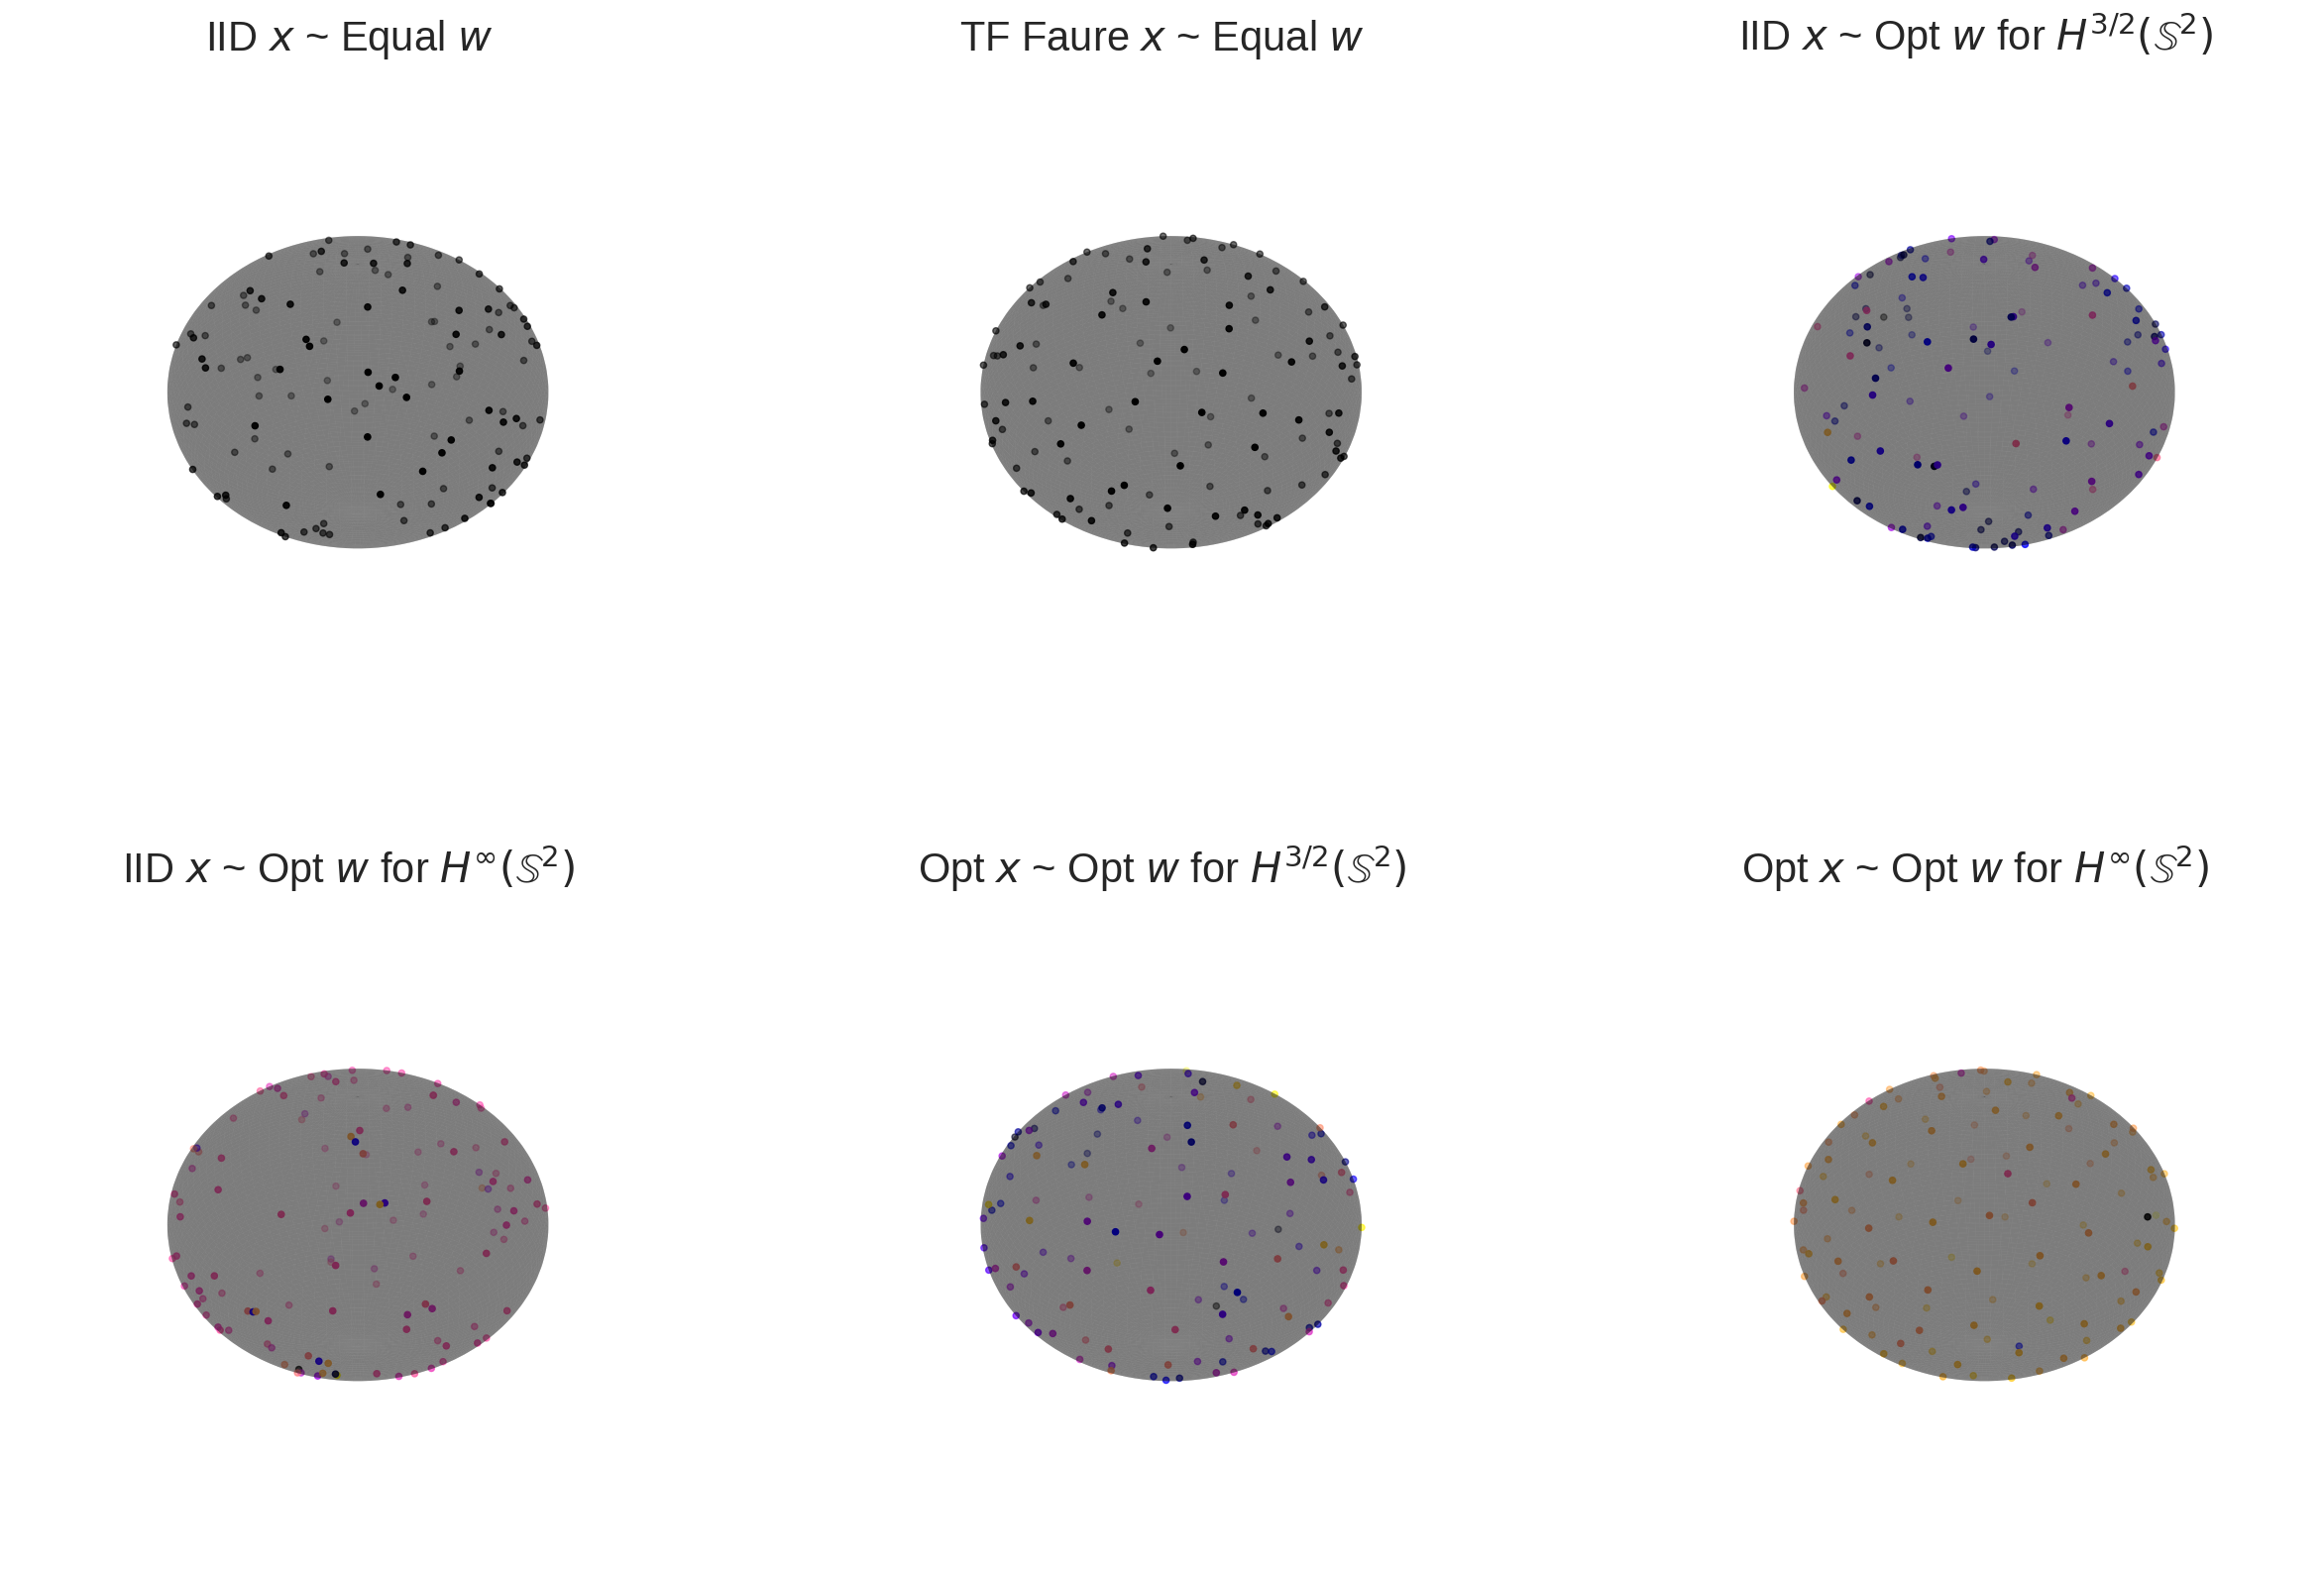

In [123]:
def get_spheres_fig_ax(nrows=1,ncols=1,showaxis=False,figwidth=PW,alpha=.3):
    fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(figwidth,figwidth/ncols*nrows),subplot_kw={"projection":"3d"})
    ax = np.atleast_1d(ax).reshape((nrows,ncols))
    phimesh,thetamesh = torch.meshgrid(torch.linspace(0,np.pi,100),torch.linspace(0,2*np.pi,100),indexing="ij")
    xmesh = torch.sin(phimesh)*torch.cos(thetamesh)
    ymesh = torch.sin(phimesh)*torch.sin(thetamesh)
    zmesh = torch.cos(phimesh)
    for i in range(nrows):
        for j in range(ncols):
            ax[i,j].plot_surface(xmesh,ymesh,zmesh,rstride=1,cstride=1,color='k',alpha=alpha,linewidth=0)
            if not showaxis:
                ax[i,j].axis("off")
    return fig,ax
rng = torch.Generator().manual_seed(17)
n = 2**7
data = {
    r"IID $x$ ~ Equal $w$": get_sphere_iid_x_equal_w(n,rng), 
    r"TF Faure $x$ ~ Equal $w$": get_sphere_ldtf_x_equal_w(n,rng),
    r"IID $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$": get_sphere_iid_x_opt_w_A(n,rng),
    r"IID $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$": get_sphere_iid_x_opt_w_B(n,rng),
    r"Opt $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$": get_sphere_opt_x_opt_w_A(n,rng),
    r"Opt $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$": get_sphere_opt_x_opt_w_B(n,rng),
}
nrows,ncols = 2,3
fig,ax = get_spheres_fig_ax(nrows=nrows,ncols=ncols)
for j,(key,(x,w)) in enumerate(data.items()):
    j1,j2 = j//ncols,j%ncols
    assert torch.allclose(torch.linalg.norm(x,dim=-1),torch.ones(1))
    ax[j1,j2].scatter(x[:,0],x[:,1],x[:,2],cmap="gnuplot2",c=w)
    ax[j1,j2].set_title(key)